In [13]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [14]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "train.csv"

data = pd.read_csv(DATA_PATH, sep=';')

In [21]:
import torch
import torch.nn as nn

class DAEImputer(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 16):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, latent_dim),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, input_dim) 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))

In [ ]:
def train_dae(
    model: nn.Module, 
    X_scaled: np.ndarray, 
    observed_mask: np.ndarray,
    corruption_rate: float = 0.25,
    epochs: int = 60,
    batch_size: int = 256,
    lr: float = 1e-3
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_scaled, dtype=torch.float32),
        torch.tensor(observed_mask, dtype=torch.float32)
    )
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for batch_x, batch_obs_mask in loader:
            random_noise_mask = (torch.rand_like(batch_x) > corruption_rate).float()
            
            input_mask = batch_obs_mask * random_noise_mask

            corrupted_x = batch_x * input_mask
            
            optimizer.zero_grad()
            reconstructed = model(corrupted_x)

            target_mask = batch_obs_mask * (1.0 - random_noise_mask)
            
            if target_mask.sum() == 0:
                continue
                
            loss = ((reconstructed - batch_x) ** 2 * target_mask).sum() / target_mask.sum()
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs} | Loss (Masked MSE): {total_loss / len(loader):.5f}")

def impute_logs(model: nn.Module, X_scaled: np.ndarray, observed_mask: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        x_input = x_tensor * torch.tensor(observed_mask, dtype=torch.float32)
        
        reconstructed = model(x_input).numpy()

        X_imputed = np.where(observed_mask == 1, X_scaled, reconstructed)
        
    return X_imputed

In [ ]:
feature_cols = ['GR', 'RHOB', 'NPHI', 'BS', 'DTC', 'DTS', 'CALI']

observed_mask = (~data[feature_cols].isna()).astype(int).values

df_filled = data[feature_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filled)

dae_model = DAEImputer(input_dim=len(feature_cols), latent_dim=8)
train_dae(dae_model, X_scaled, observed_mask, corruption_rate=0.3, epochs=130)

X_imputed_scaled = impute_logs(dae_model, X_scaled, observed_mask)

df_imputed = pd.DataFrame(
    scaler.inverse_transform(X_imputed_scaled), 
    columns=feature_cols, 
    index=data.index
)

Epoch 01/130 | Loss (Masked MSE): 0.31750
Epoch 10/130 | Loss (Masked MSE): 0.28439
Epoch 20/130 | Loss (Masked MSE): 0.27937
Epoch 30/130 | Loss (Masked MSE): 0.27886
Epoch 40/130 | Loss (Masked MSE): 0.27700
Epoch 50/130 | Loss (Masked MSE): 0.27721
Epoch 60/130 | Loss (Masked MSE): 0.27633
Epoch 70/130 | Loss (Masked MSE): 0.27544
Epoch 80/130 | Loss (Masked MSE): 0.27782
Epoch 90/130 | Loss (Masked MSE): 0.27756
Epoch 100/130 | Loss (Masked MSE): 0.27463
Epoch 110/130 | Loss (Masked MSE): 0.27492
Epoch 120/130 | Loss (Masked MSE): 0.27602
Epoch 130/130 | Loss (Masked MSE): 0.27500


In [ ]:
import sys
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# Добавляем корень проекта
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.models.baseline import Baseline
from src.metrics import LithologyEvaluator

def run_dae_baseline_experiment(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "FORCE_2020_LITHOFACIES_LITHOLOGY",
    latent_dim: int = 16,
    epochs: int = 40,
    reports_dir: str = "reports/figures/dae_baseline",
):
    """
    Полный цикл: DAE-импутация -> Baseline classification -> Метрики и графики.
    """
    print("=" * 50)
    print("ЗАПУСК: DAE + BASELINE")
    print("=" * 50)

    print("\n[1/4] Подготовка масок и StandardScaler...")
    X_raw = df[feature_cols].values
    observed_mask = ~np.isnan(X_raw)

    scaler = StandardScaler()
    X_filled_temp = df[feature_cols].fillna(df[feature_cols].median()).values
    X_scaled = scaler.fit_transform(X_filled_temp)

    X_scaled_input = np.where(observed_mask, X_scaled, 0.0)

    print(f"\n[2/4] Обучение DAE (latent_dim={latent_dim}, epochs={epochs})...")
    dae_model = DAEImputer(input_dim=len(feature_cols), latent_dim=latent_dim)
    
    train_dae(
        model=dae_model,
        X_scaled=X_scaled_input,
        observed_mask=observed_mask.astype(np.float32),
        corruption_rate=0.3,
        epochs=epochs,
        batch_size=256,
        lr=1e-3,
    )

    print("\n[3/4] Восстановление пропусков через DAE...")
    dae_model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(X_scaled_input, dtype=torch.float32)
        reconstructed_scaled = dae_model(x_tensor).numpy()

    X_imputed_scaled = np.where(observed_mask, X_scaled, reconstructed_scaled)
    X_imputed = scaler.inverse_transform(X_imputed_scaled)


    df_dae = df.copy()
    df_dae[feature_cols] = X_imputed

   
    print("\n[4/4] Обучение и оценка Baseline на DAE-данных...")
    trainer = Baseline(test_size=0.2, random_state=42)
    metrics = trainer.fit_eval(df_dae)


    val_preds = trainer.predict(trainer.X_val)
    val_probs = trainer.predict_proba(trainer.X_val)
    classes = trainer.pipeline.classes_

    evaluator = LithologyEvaluator()
    evaluator.plot_all(
        y_true=trainer.y_val,
        y_pred=val_preds,
        val_probs=val_probs,
        classes=classes,
        output_dir=reports_dir,
    )

    print("\n" + "=" * 50)
    print(f"Эксперимент завершен! Отчеты сохранены в: {reports_dir}")
    print("=" * 50)

    return metrics, df_dae

🚀 ЗАПУСК ЭКСПЕРИМЕНТА: DAE + BASELINE

[1/4] Подготовка масок и StandardScaler...

[2/4] Обучение DAE (latent_dim=16, epochs=50)...
Epoch 01/50 | Loss (Masked MSE): 0.79712
Epoch 10/50 | Loss (Masked MSE): 0.70988
Epoch 20/50 | Loss (Masked MSE): 0.68400
Epoch 30/50 | Loss (Masked MSE): 0.68886
Epoch 40/50 | Loss (Masked MSE): 0.67573
Epoch 50/50 | Loss (Masked MSE): 0.67029

[3/4] Восстановление пропусков через DAE...

[4/4] Обучение и оценка Baseline на DAE-данных...
Обучение SGDClassifier baseline >>> 


/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(



 Отчет по классификации (Validation):
              precision    recall  f1-score   support

       30000       0.64      0.79      0.71     37982
       65000       0.88      0.87      0.87    176056
       65030       0.47      0.29      0.36     29272
       70000       0.48      0.55      0.51     12431
       70032       0.61      0.93      0.74      2575
       74000       0.04      0.04      0.04       495
       80000       0.39      0.36      0.37     10940
       86000       0.56      0.37      0.45       240
       88000       0.95      0.90      0.92      3899
       90000       0.20      0.75      0.31       514
       93000       0.00      0.00      0.00         0
       99000       0.64      0.91      0.75      1838

    accuracy                           0.76    276242
   macro avg       0.49      0.56      0.50    276242
weighted avg       0.76      0.76      0.76    276242



/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Матрица ошибок сохранена в: reports/figures/dae_baseline/confusion_matrix.png


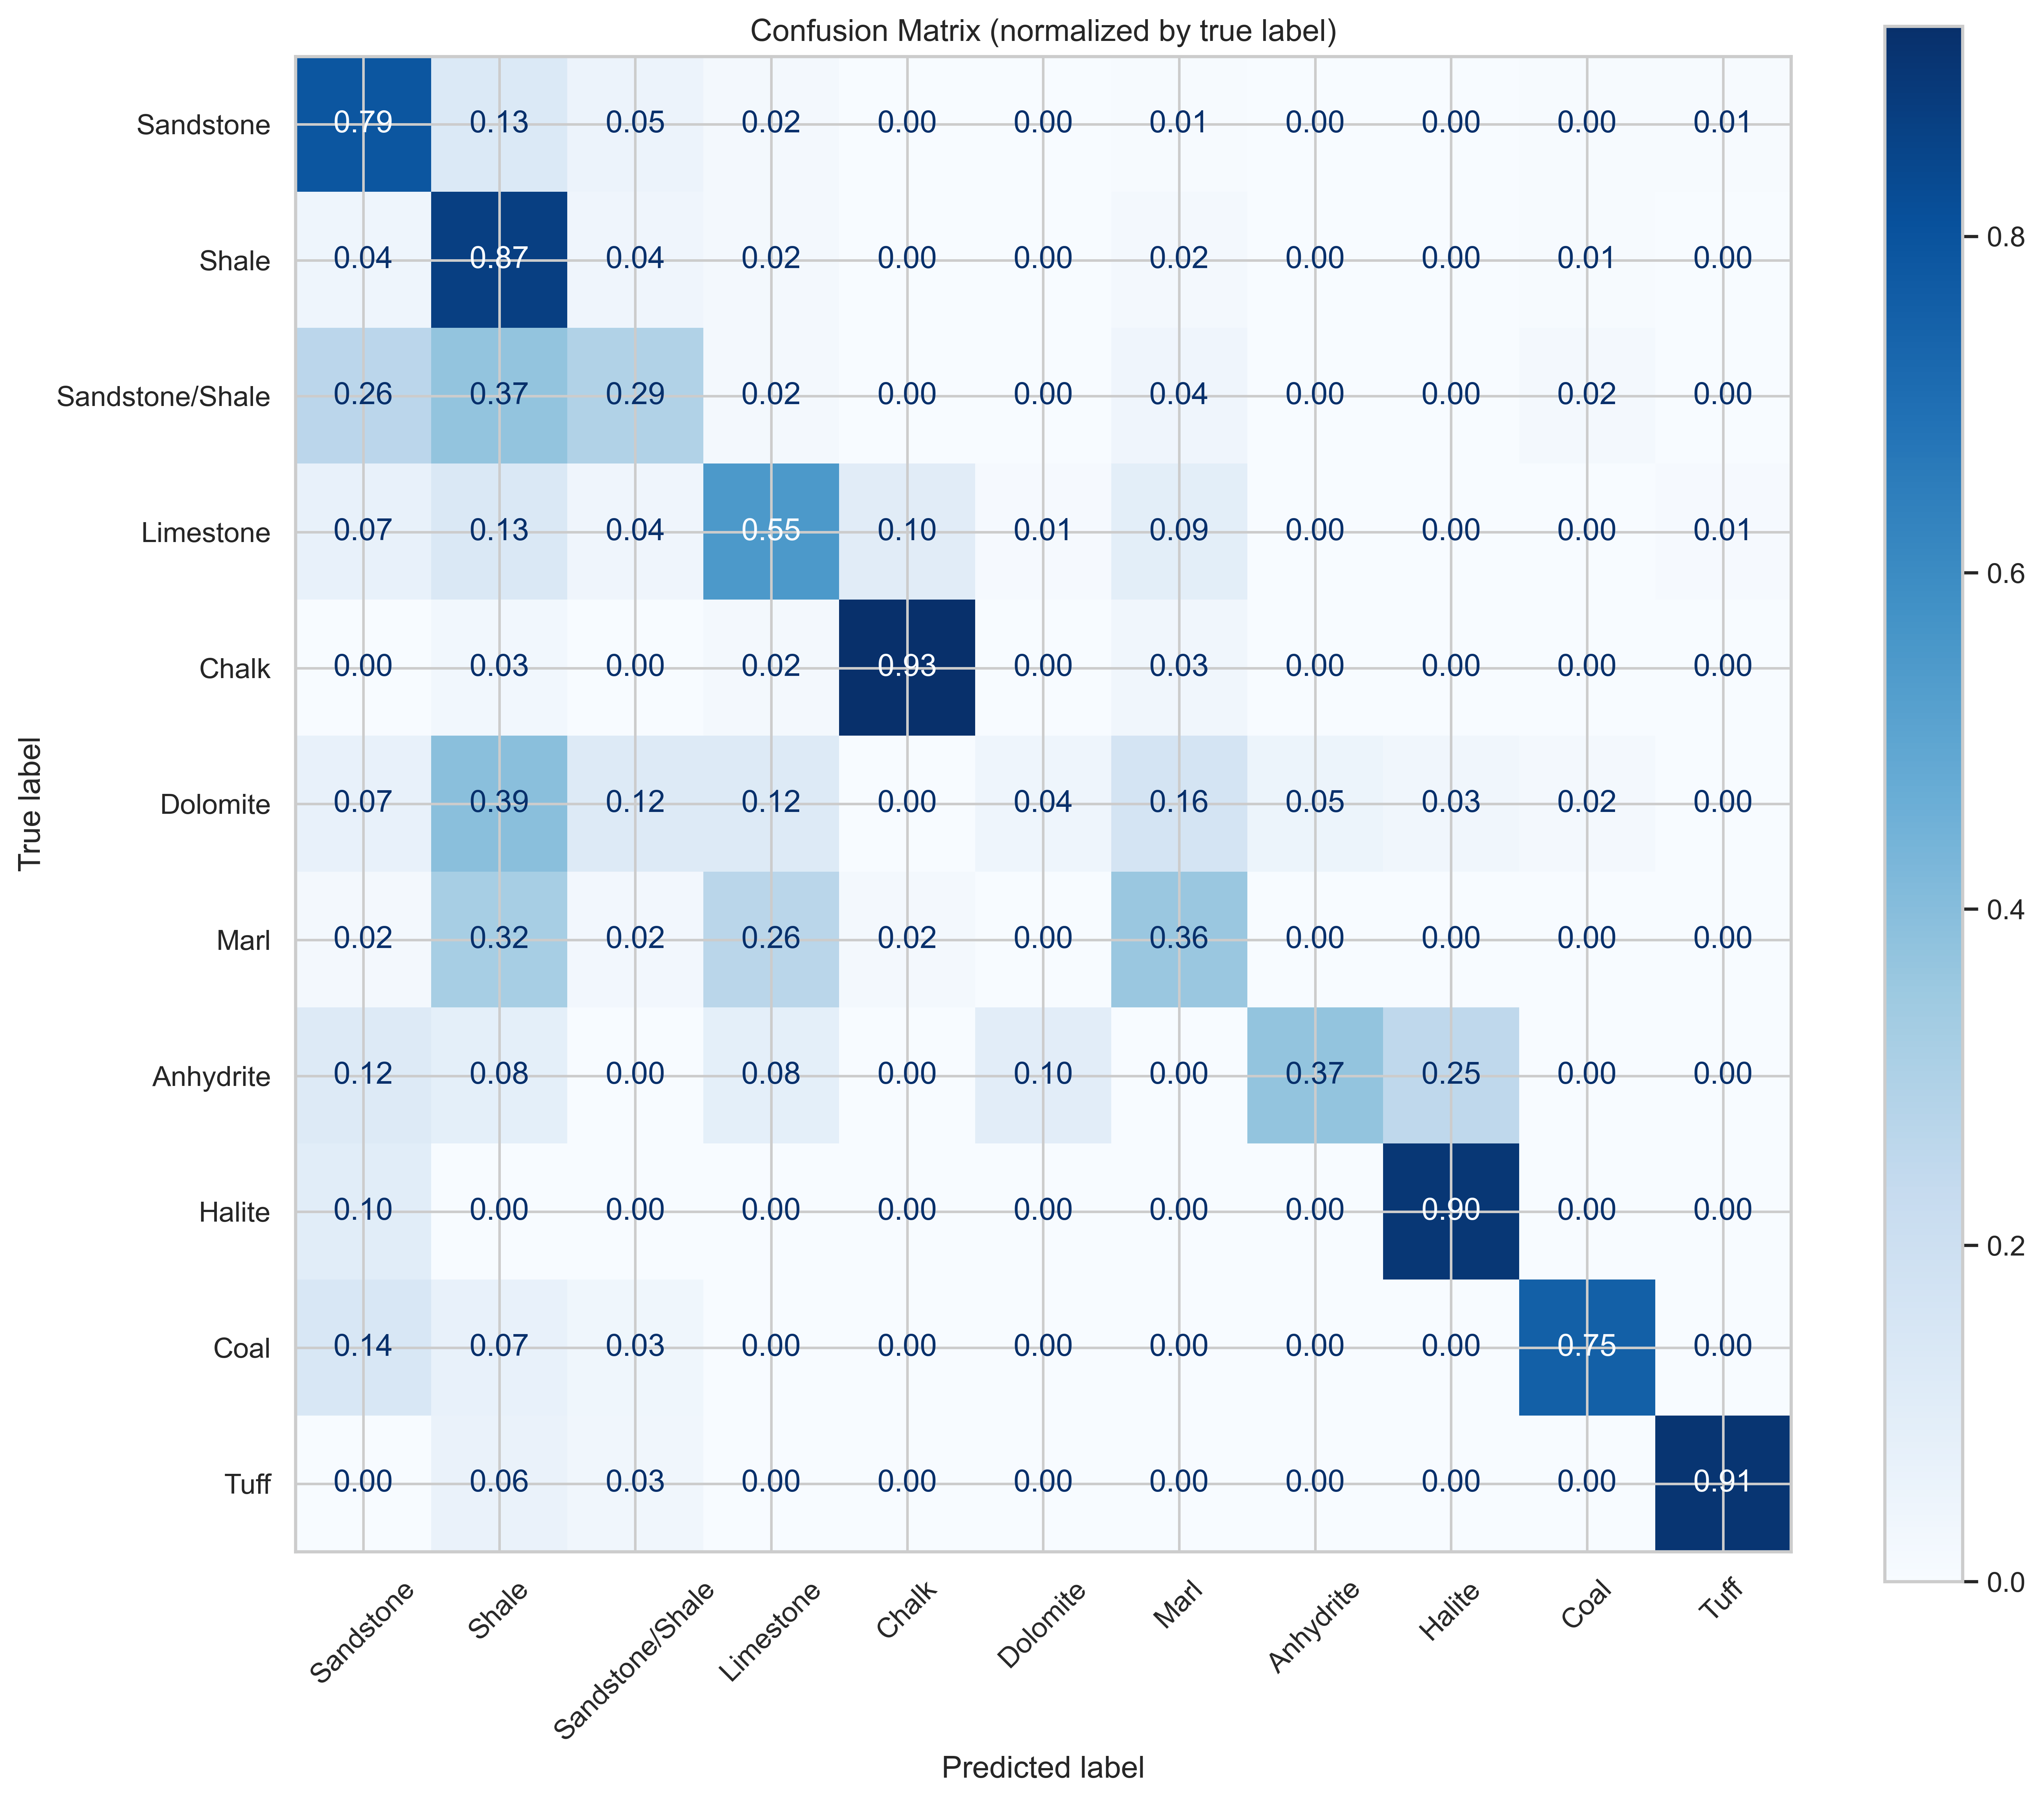

ROC-AUC графики сохранены в: reports/figures/dae_baseline/roc_auc_curves.png


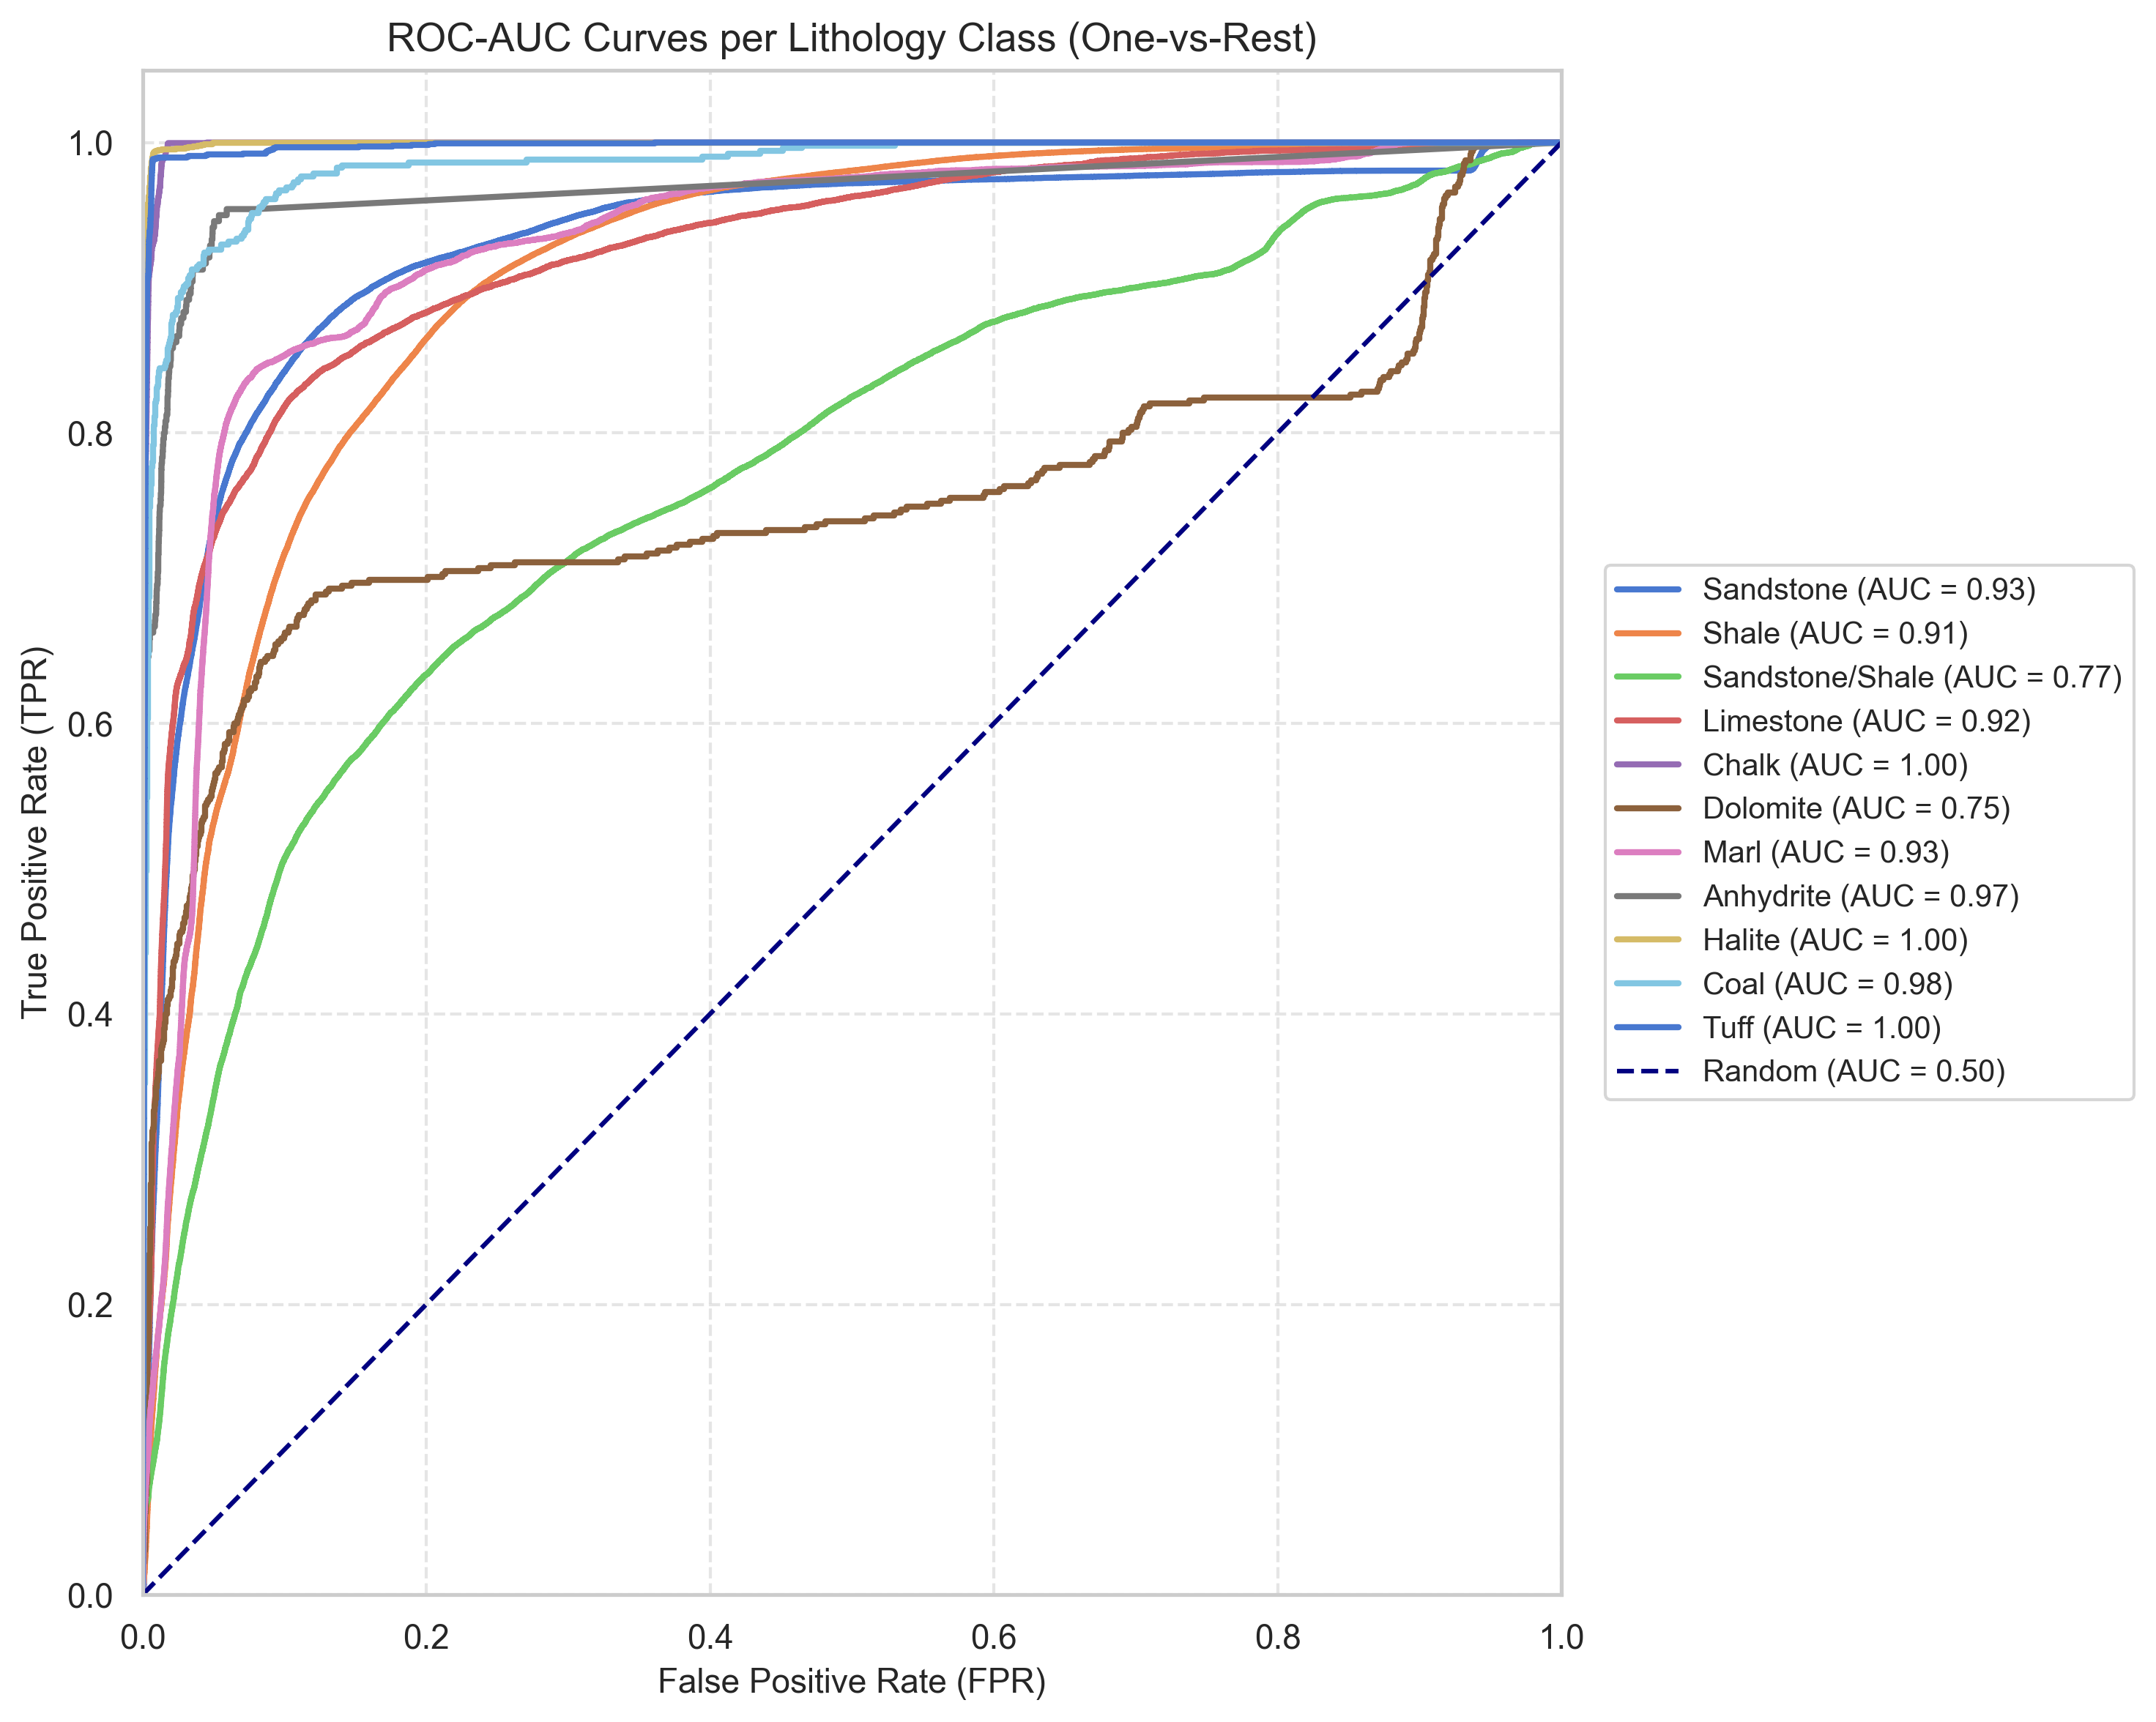


✅ Эксперимент завершен! Отчеты сохранены в: reports/figures/dae_baseline


In [ ]:
feature_cols = ['RDEP', 'RMED', 'RSHA', 'RHOB', 'GR', 'NPHI', 'DTC']

metrics, df_imputed = run_dae_baseline_experiment(
    df=data, 
    feature_cols=feature_cols,
    latent_dim=16,
    epochs=50
)

Загрузка данных...

[1/5] Подготовка масок и масштабирование (scaler fit на TRAIN)...

[2/5] Обучение DAE на обучающей выборке...
Epoch 01/50 | Loss (Masked MSE): 0.80042
Epoch 10/50 | Loss (Masked MSE): 0.72041
Epoch 20/50 | Loss (Masked MSE): 0.68307
Epoch 30/50 | Loss (Masked MSE): 0.69528
Epoch 40/50 | Loss (Masked MSE): 0.68408
Epoch 50/50 | Loss (Masked MSE): 0.69117

[3/5] Восстановление пропусков через DAE...

[4/5] Обучение Baseline на восстановленном TRAIN...
Обучение SGDClassifier baseline >>> 


/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(



 Отчет по классификации (Validation):
              precision    recall  f1-score   support

       30000       0.64      0.79      0.71     37982
       65000       0.88      0.87      0.87    176056
       65030       0.47      0.29      0.36     29272
       70000       0.47      0.52      0.49     12431
       70032       0.54      0.85      0.66      2575
       74000       0.02      0.03      0.02       495
       80000       0.39      0.36      0.38     10940
       86000       0.55      0.40      0.46       240
       88000       0.97      0.80      0.88      3899
       90000       0.20      0.76      0.31       514
       93000       0.00      0.00      0.00         0
       99000       0.63      0.91      0.74      1838

    accuracy                           0.76    276242
   macro avg       0.48      0.55      0.49    276242
weighted avg       0.76      0.76      0.75    276242



/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize


[5/5] Оценка классификатора на TEST...
Матрица ошибок сохранена в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/dae_baseline_test/confusion_matrix.png


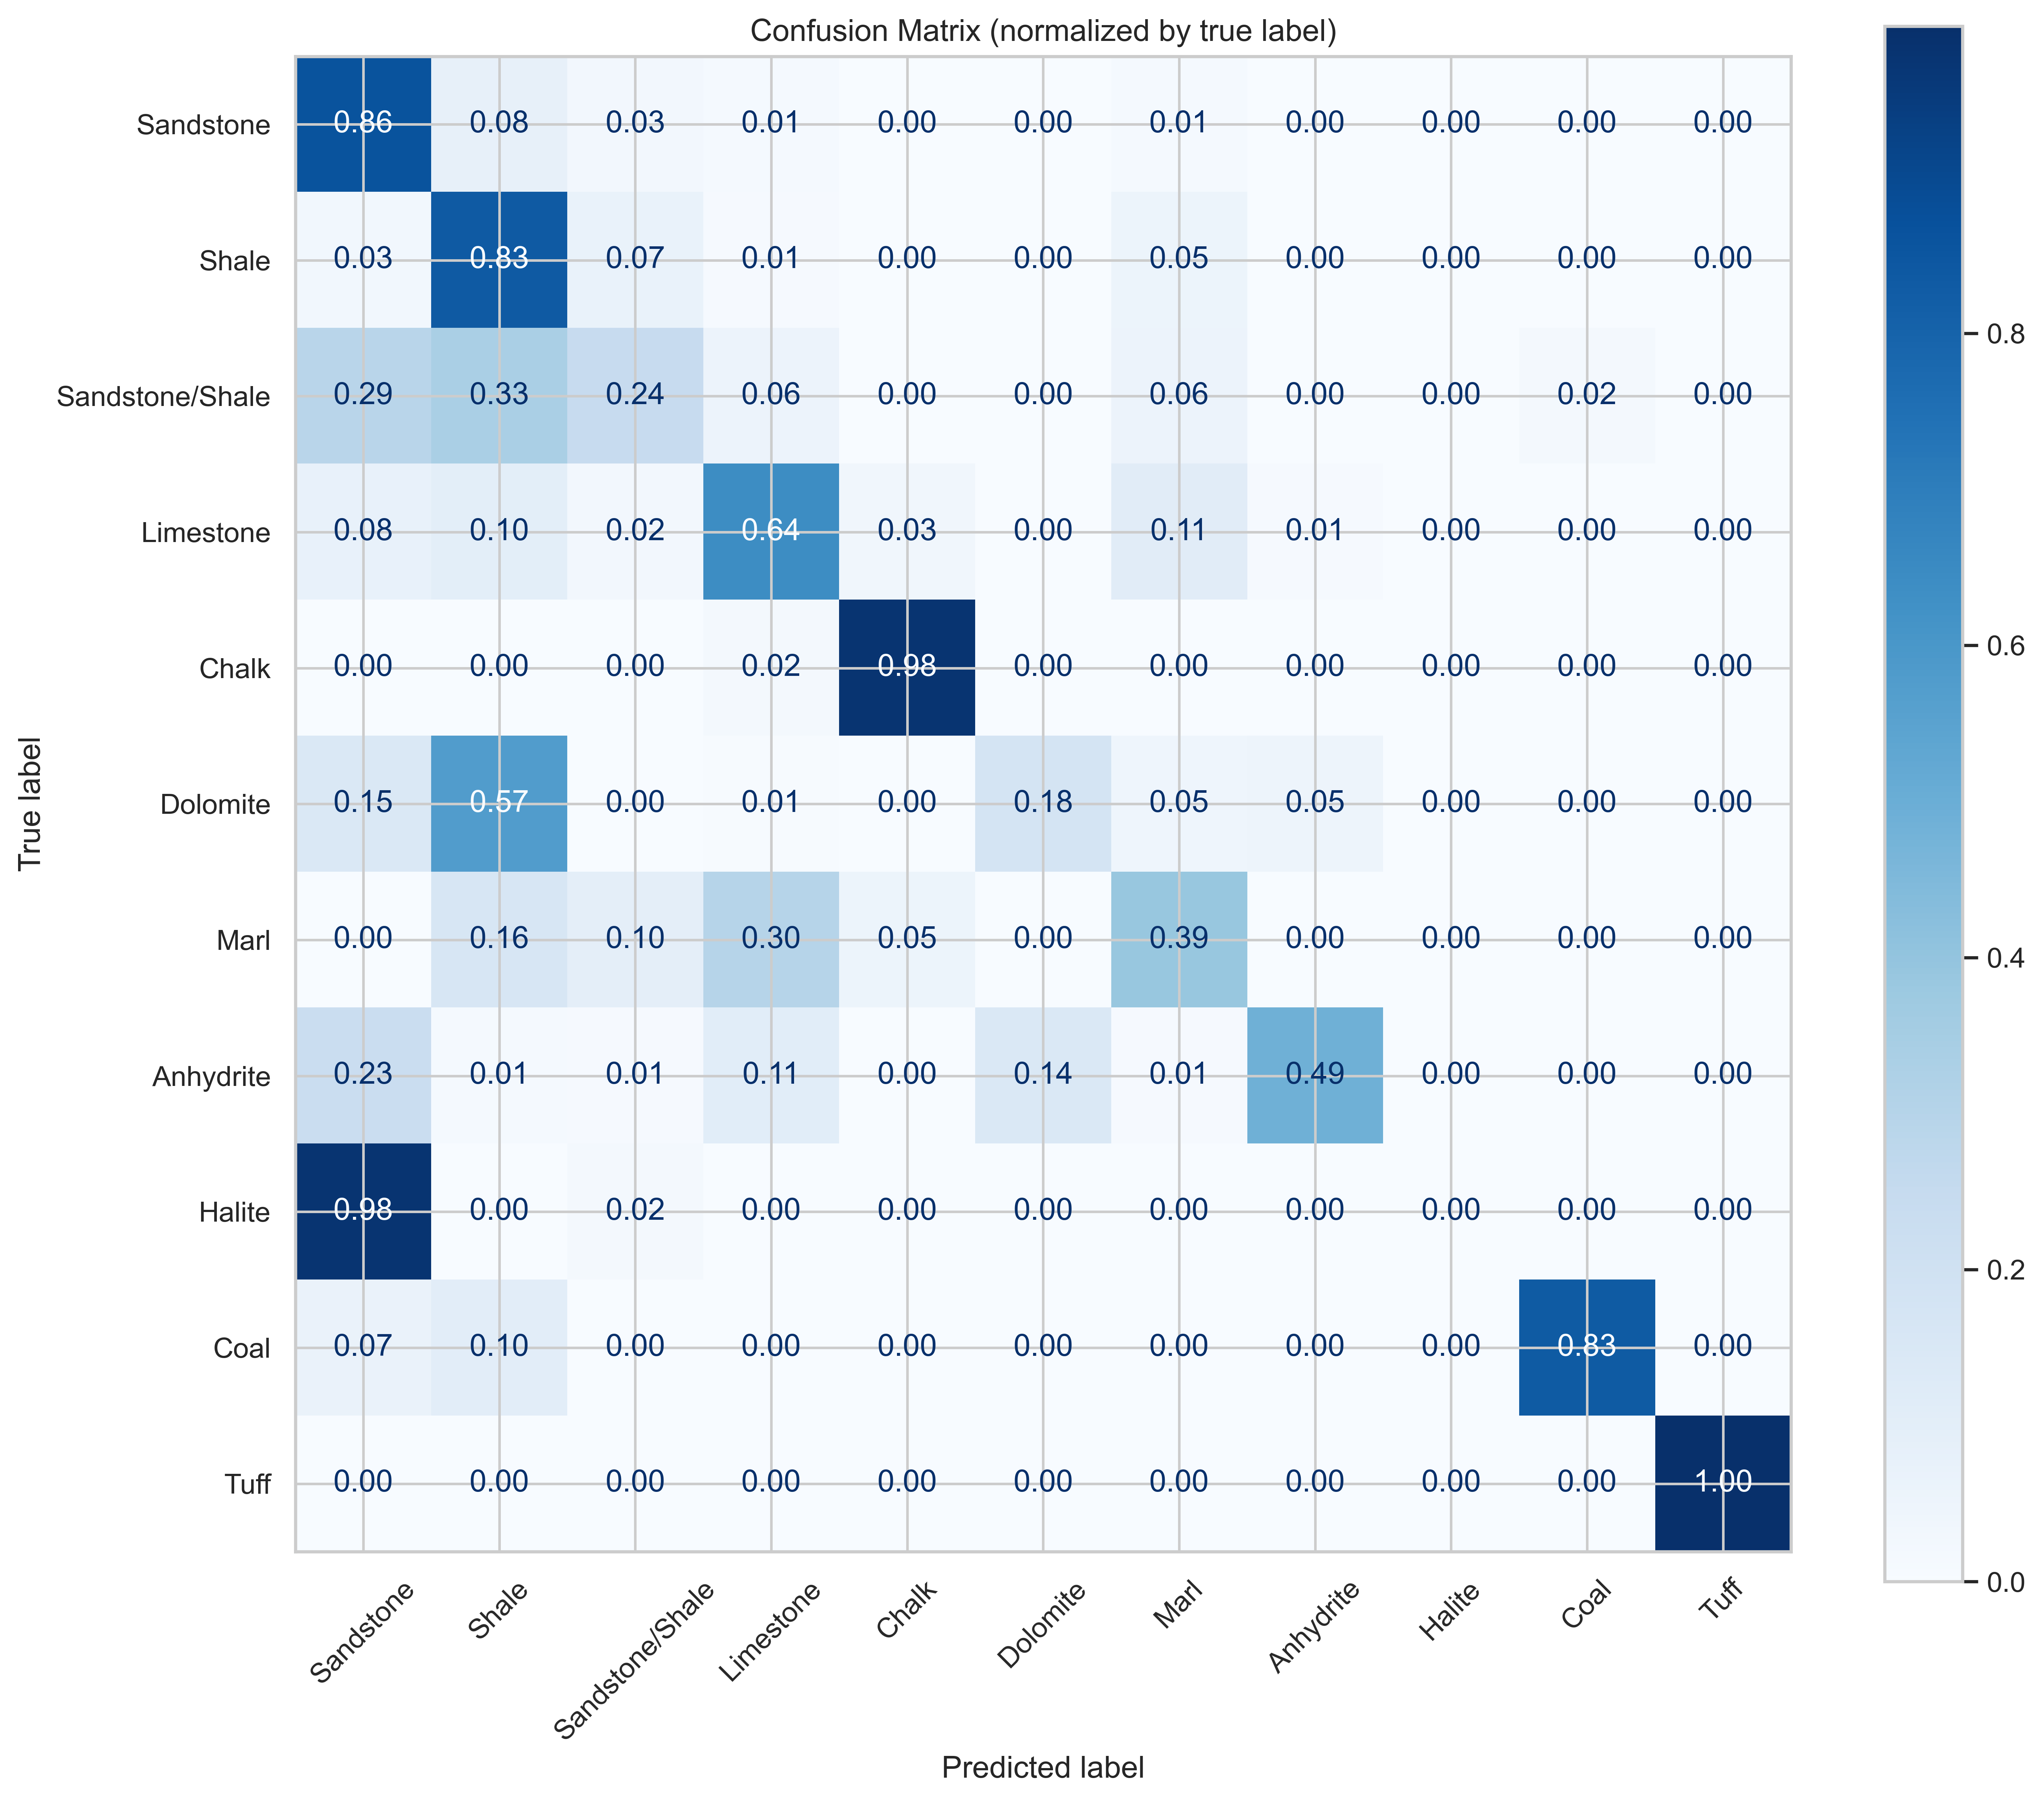

ROC-AUC графики сохранены в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/dae_baseline_test/roc_auc_curves.png


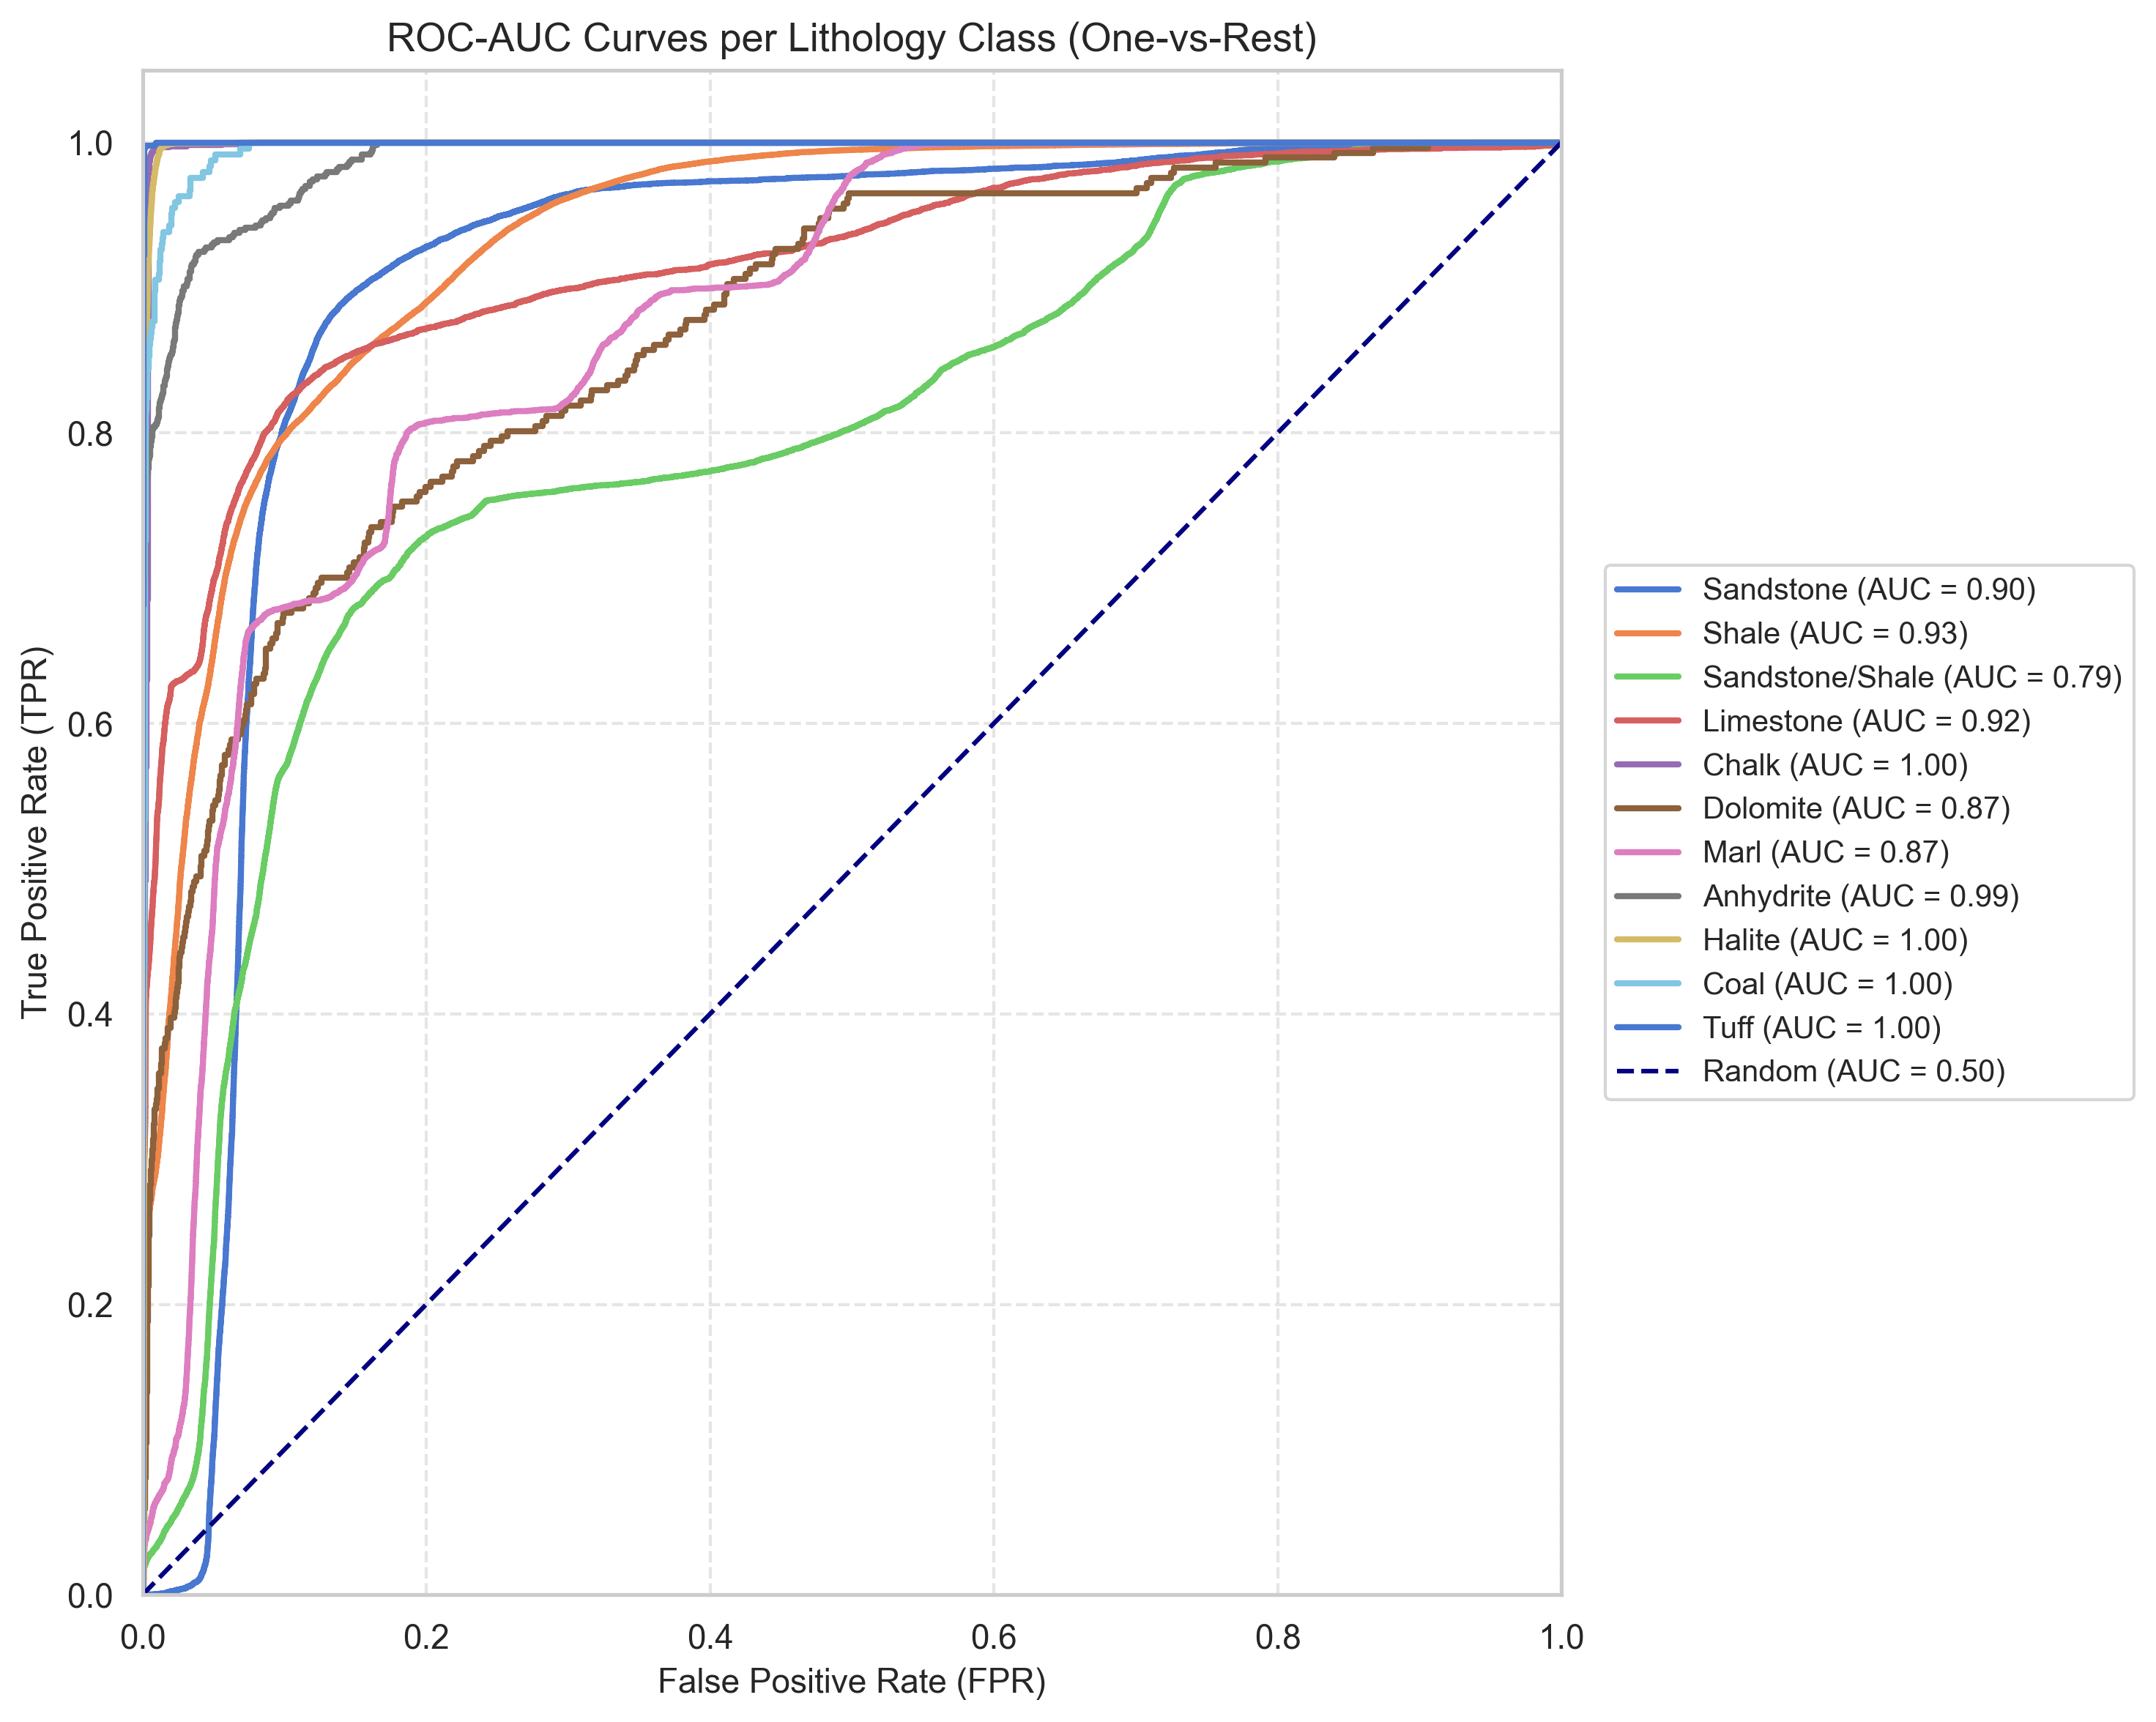


 Проверка на тесте. Графики сохранены в reports/figures/dae_baseline_test


In [29]:
import sys
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.models.baseline import Baseline
from src.metrics import LithologyEvaluator

TRAIN_PATH = BASE_DIR / "data" / "raw" / "train.csv"
TEST_PATH = BASE_DIR / "data" / "raw" / "hidden_test.csv"

print("Загрузка данных...")
df_train = pd.read_csv(TRAIN_PATH, sep=';')
df_test = pd.read_csv(TEST_PATH, sep=';')

feature_cols = ['RDEP', 'RMED', 'RSHA', 'RHOB', 'GR', 'NPHI', 'DTC']
target_col = 'FORCE_2020_LITHOFACIES_LITHOLOGY'

# --- [ЭТАП 1] Масштабирование без утечки данных ---
print("\n[1/5] Подготовка масок и масштабирование (scaler fit на TRAIN)...")
scaler = StandardScaler()

train_medians = df_train[feature_cols].median()

X_train_raw = df_train[feature_cols].values
train_obs_mask = ~np.isnan(X_train_raw)
X_train_filled = df_train[feature_cols].fillna(train_medians).values
X_train_scaled = scaler.fit_transform(X_train_filled)
X_train_scaled_input = np.where(train_obs_mask, X_train_scaled, 0.0)

X_test_raw = df_test[feature_cols].values
test_obs_mask = ~np.isnan(X_test_raw)
X_test_filled = df_test[feature_cols].fillna(train_medians).values
X_test_scaled = scaler.transform(X_test_filled)
X_test_scaled_input = np.where(test_obs_mask, X_test_scaled, 0.0)

# --- [ЭТАП 2] Обучение DAE на TRAIN ---
print("\n[2/5] Обучение DAE на обучающей выборке...")
dae_model = DAEImputer(input_dim=len(feature_cols), latent_dim=16)

train_dae(
    model=dae_model,
    X_scaled=X_train_scaled_input,
    observed_mask=train_obs_mask.astype(np.float32),
    corruption_rate=0.3,
    epochs=50,
    batch_size=256,
    lr=1e-3,
)

# --- [ЭТАП 3] Восстановление пропусков ---
print("\n[3/5] Восстановление пропусков через DAE...")
dae_model.eval()
with torch.no_grad():
    rec_train = dae_model(torch.tensor(X_train_scaled_input, dtype=torch.float32)).numpy()
    X_tr_imp_scaled = np.where(train_obs_mask, X_train_scaled, rec_train)
    X_train_imputed = scaler.inverse_transform(X_tr_imp_scaled)
    
    rec_test = dae_model(torch.tensor(X_test_scaled_input, dtype=torch.float32)).numpy()
    X_te_imp_scaled = np.where(test_obs_mask, X_test_scaled, rec_test)
    X_test_imputed = scaler.inverse_transform(X_te_imp_scaled)
    
df_train_dae = df_train.copy()
df_train_dae[feature_cols] = X_train_imputed

df_test_dae = df_test.copy()
df_test_dae[feature_cols] = X_test_imputed

# --- [ЭТАП 4] Обучение Baseline на TRAIN ---
print("\n[4/5] Обучение Baseline на восстановленном TRAIN...")
trainer = Baseline(test_size=0.2, random_state=42)
trainer.fit_eval(df_train_dae)

# --- [ЭТАП 5] Проверка Baseline на TEST ---
print("\n[5/5] Оценка классификатора на TEST...")
y_test = df_test_dae[target_col]

test_preds = trainer.predict(df_test_dae)
test_probs = trainer.predict_proba(df_test_dae)
classes = trainer.pipeline.classes_

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=y_test,
    y_pred=test_preds,
    val_probs=test_probs,
    classes=classes,
    output_dir=str(BASE_DIR / "reports" / "figures" / "dae_baseline_test"),
)

print("\n Проверка на тесте. Графики сохранены в reports/figures/dae_baseline_test")